**Problem Statement and Analysing basic metrics**


**About Aerofit**

---

Aerofit is a leading brand in the field of fitness equipment. Aerofit provides a product range including machines such as treadmills, exercise bikes, gym equipment, and fitness accessories to cater to the needs of all categories of people.

**About Data**

---

The company collected the data on individuals who purchased a treadmill from the AeroFit stores during the prior three months.

**Business Problem**

---


The market research team at AeroFit wants to identify the characteristics of the target audience for each type of treadmill offered by the company, to provide a better recommendation of the treadmills to the new customers. The team decides to investigate whether there are differences across the product with respect to customer characteristics.

**Dataset Features**

---

**Product Purchased:** 	KP281, KP481, or KP781

**Age:**	In years

**Gender:**	Male/Female

**Education:**	In years

**MaritalStatus:**	Single or partnered

**Usage:**	The average number of times the customer plans to use the treadmill each week.

**Income:**	Annual income (in $)

**Fitness:**	Self-rated fitness on a 1-to-5 scale, where 1 is the poor shape and 5 is the excellent shape.

**Miles:**	The average number of miles the customer expects to walk/run each week



**Product Portfolio**

---



*   The KP281 is an entry-level treadmill that sells for $1,500

*   The KP481 is for mid-level runners that sell for $1,750

*   The KP781 treadmill is having advanced features that sell for $2,500








In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import binom
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/aerofit_treadmill.csv")

In [ ]:
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [ ]:
df.tail()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
175,KP781,40,Male,21,Single,6,5,83416,200
176,KP781,42,Male,18,Single,5,4,89641,200
177,KP781,45,Male,16,Single,5,5,90886,160
178,KP781,47,Male,18,Partnered,4,5,104581,120
179,KP781,48,Male,18,Partnered,4,5,95508,180


In [ ]:
df.shape   #using df.shape we come to know the given dataset have 180 rows and 9 columns

(180, 9)

In [ ]:
df.ndim   #using df.ndim we come to know the given dataset is of 2 dimnesion

2

**Checking Data Types of each column**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB




*   Age, Education, Usage, Fitness, Income & Miles Columns are of Integer datatype

* Product, Gender, MaritalStatus are of Object datatype   





**Checking Null Values in the Dataset**

In [ ]:
df.isnull().sum()

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


**Insights**

---



*   The given dataset have 180 rows and 9 columns.

*   The given dataset is of 2 dimnesion.

  
*   Age, Education, Usage, Fitness, Income & Miles Columns are of Integer datatype

* Product, Gender, MaritalStatus are of Object datatype  


* We found that there are no null or missing values






**Unique Attributes & Value_Counts of Columns**




In [ ]:
for i in df.columns:
    print(f"Unique Value of {i}:")
    print(df[i].unique())
    print("-"*50)
    print(f"Total No of {i}: ", df[i].nunique())
    print("-"*50)
    print(f"Value Count of {i}:")
    print(df[i].value_counts().sort_values(ascending= False).head(5))
    print("-"*50)
    print()

Unique Value of Product:
['KP281' 'KP481' 'KP781']
--------------------------------------------------
Total No of Product:  3
--------------------------------------------------
Value Count of Product:
Product
KP281    80
KP481    60
KP781    40
Name: count, dtype: int64
--------------------------------------------------

Unique Value of Age:
[18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41
 43 44 46 47 50 45 48 42]
--------------------------------------------------
Total No of Age:  32
--------------------------------------------------
Value Count of Age:
Age
25    25
23    18
24    12
26    12
28     9
Name: count, dtype: int64
--------------------------------------------------

Unique Value of Gender:
['Male' 'Female']
--------------------------------------------------
Total No of Gender:  2
--------------------------------------------------
Value Count of Gender:
Gender
Male      104
Female     76
Name: count, dtype: int64
------------------------------------

**Insights**

---




*   There are 3 different types of Treadmill.

*   Most Purchased product is KP281.

*   32 Unique Age groups available.

*   104 Male Customers and 76 Female Customers.

*   There are total 8 unique educational levels.

*   107 customers are married and 73 are single.

*   Most customers use the treadmill atleast 3 times per week.

*   Most of the customers rated their fitness rating as 3.



**Statistical Summary**

---




In [ ]:
# statisctical summary of numerical data type columns
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


**Insights**

---

1. Age: The age of customers spans from 18 to 50 year, with an average age of 29 years.

2. Education: Customer education levels vary between 12 and 21 years, with an average education duration of 16 years.

3. Usage: Customers intend to utilize the product anywhere from 2 to 7 times per week, with an average usage frequency of 3 times per week.

4. Fitness: On average, customers have rated their fitness at 3 on a 5-point scale, reflecting a moderate level of fitness.

5. Income: The annual income of customers falls within the range of USD 29,562 to USD 1,04,581 with an average income of approximately USD 53,719.

6. Miles:  Customers' weekly running goals range from 21 to 360 miles, with an average target of 103 miles per week.



In [ ]:
# statisctical summary of object data type columns
df.describe(include = 'object')

,Product,Gender,MaritalStatus
count,180,180,180
unique,3,2,2
top,KP281,Male,Partnered
freq,80,104,107


**Insights**

---

1. Product: The KP281 product demonstrated the highest sales performance among the three products, accounting for approximately 44% of total sales.

2. Gender: Around 58% of the buyers were Male and 42% were female.

3. Marital Status: Around 60% of the buyers were Married and 40% were single

**Creating New Columns for Better Analysis**



***New Column for Age Group***

---


*   Categorizing the Age Column into 3 Category.

*   Adult: (17-29]

*   Middle_Aged: (29 - 45]

*   Old: (46 & Above]









In [ ]:
age_bins= [17,29,45,df["Age"].max()]
age_label = ["Adult", "Middle_Aged", "Old"]
df["Age_group"] = pd.cut(df["Age"], bins = age_bins, labels = age_label)
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_group
0,KP281,18,Male,14,Single,3,4,29562,112,Adult
1,KP281,19,Male,15,Single,2,3,31836,75,Adult
2,KP281,19,Female,14,Partnered,4,3,30699,66,Adult
3,KP281,19,Male,12,Single,3,3,32973,85,Adult
4,KP281,20,Male,13,Partnered,4,2,35247,47,Adult


***New Column for Usage Group***

---



*   Categorizing the Usage Column into 3 Category.

*   Low_Usage: (1-3] Usage per week.

*   Medium_Usage: (3-5] Usage per week.

*   High_Usage: (5-7] Usage per week.





In [ ]:
usage_bins= [1,3,5,7]
usage_label = ["Low_Usage", "Medium_Usage", "High_Usage"]
df["Usage_group"] = pd.cut(df["Usage"], bins = usage_bins, labels = usage_label)
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_group,Usage_group
0,KP281,18,Male,14,Single,3,4,29562,112,Adult,Low_Usage
1,KP281,19,Male,15,Single,2,3,31836,75,Adult,Low_Usage
2,KP281,19,Female,14,Partnered,4,3,30699,66,Adult,Medium_Usage
3,KP281,19,Male,12,Single,3,3,32973,85,Adult,Low_Usage
4,KP281,20,Male,13,Partnered,4,2,35247,47,Adult,Medium_Usage


***New Column for Fitness Group***

---


*   Categorizing Fitness Column into 3 Category.

*   Low_Fitness: (0-2] Ratings.

*   Medium_Fitness: (2-3] Ratings.

*   High_Fitness: (3-5] Ratings.







In [ ]:
fitness_bins= [0,2,3,5]
fitness_label = ["Low_Fitness", "Medium_Fitness", "High_Fitness"]
df["Fitness_group"] = pd.cut(df["Fitness"], bins = fitness_bins, labels = fitness_label)
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_group,Usage_group,Fitness_group
0,KP281,18,Male,14,Single,3,4,29562,112,Adult,Low_Usage,High_Fitness
1,KP281,19,Male,15,Single,2,3,31836,75,Adult,Low_Usage,Medium_Fitness
2,KP281,19,Female,14,Partnered,4,3,30699,66,Adult,Medium_Usage,Medium_Fitness
3,KP281,19,Male,12,Single,3,3,32973,85,Adult,Low_Usage,Medium_Fitness
4,KP281,20,Male,13,Partnered,4,2,35247,47,Adult,Medium_Usage,Low_Fitness


***New Column for Income Group***

---


*   Categorizing the Income Column into 3 Category.

*   Low_Income: (0-40000]

*   Medium_Income: (40000-70000]

*   High_Income: (70000 & Above]










In [ ]:
income_bins= [0,40000,70000,df["Income"].max()]
income_label = ["Low_Income", "Medium_Income", "High_Income"]
df["Income_group"] = pd.cut(df["Income"], bins = income_bins, labels = income_label)
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_group,Usage_group,Fitness_group,Income_group
0,KP281,18,Male,14,Single,3,4,29562,112,Adult,Low_Usage,High_Fitness,Low_Income
1,KP281,19,Male,15,Single,2,3,31836,75,Adult,Low_Usage,Medium_Fitness,Low_Income
2,KP281,19,Female,14,Partnered,4,3,30699,66,Adult,Medium_Usage,Medium_Fitness,Low_Income
3,KP281,19,Male,12,Single,3,3,32973,85,Adult,Low_Usage,Medium_Fitness,Low_Income
4,KP281,20,Male,13,Partnered,4,2,35247,47,Adult,Medium_Usage,Low_Fitness,Low_Income


***New Column for Miles Group***

---



*   Categorizing the Miles Column into 4 Category.

*   Low_Activity: (0-50] Miles Per Week.

*   Medium_Activity: (50-100] Miles Per Week.

*   High_Activity: (100-200] Miles Per Week.

*   Very_High_Activity: Above 200 Miles Per Week








In [ ]:
miles_bins= [0,50,100,200,df["Miles"].max()]
miles_label = ["Low_Activity", "Medium_Activity", "High_Activity", "Very_High_Activity"]
df["Miles_group"] = pd.cut(df["Miles"], bins = miles_bins, labels = miles_label)
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_group,Usage_group,Fitness_group,Income_group,Miles_group
0,KP281,18,Male,14,Single,3,4,29562,112,Adult,Low_Usage,High_Fitness,Low_Income,High_Activity
1,KP281,19,Male,15,Single,2,3,31836,75,Adult,Low_Usage,Medium_Fitness,Low_Income,Medium_Activity
2,KP281,19,Female,14,Partnered,4,3,30699,66,Adult,Medium_Usage,Medium_Fitness,Low_Income,Medium_Activity
3,KP281,19,Male,12,Single,3,3,32973,85,Adult,Low_Usage,Medium_Fitness,Low_Income,Medium_Activity
4,KP281,20,Male,13,Partnered,4,2,35247,47,Adult,Medium_Usage,Low_Fitness,Low_Income,Low_Activity


***New Column for Product Price***

---


*   The KP281 is an entry-level treadmill that sells for USD 1500.

*   The KP481 is for mid-level runners that sell for USD 1750.

*   The KP781 treadmill is having advanced features that sell for USD 2500.










In [ ]:
# Creating a function for Product price
def product_price(x):
  if x == "KP281":
    return 1500
  elif x == "KP481":
    return 1750
  else:
    return 2500

In [ ]:
# Assigning the sales value of each product
df["Product_price"] = df["Product"].apply(lambda x: product_price(x))
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_group,Usage_group,Fitness_group,Income_group,Miles_group,Product_price
0,KP281,18,Male,14,Single,3,4,29562,112,Adult,Low_Usage,High_Fitness,Low_Income,High_Activity,1500
1,KP281,19,Male,15,Single,2,3,31836,75,Adult,Low_Usage,Medium_Fitness,Low_Income,Medium_Activity,1500
2,KP281,19,Female,14,Partnered,4,3,30699,66,Adult,Medium_Usage,Medium_Fitness,Low_Income,Medium_Activity,1500
3,KP281,19,Male,12,Single,3,3,32973,85,Adult,Low_Usage,Medium_Fitness,Low_Income,Medium_Activity,1500
4,KP281,20,Male,13,Partnered,4,2,35247,47,Adult,Medium_Usage,Low_Fitness,Low_Income,Low_Activity,1500


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Product        180 non-null    object  
 1   Age            180 non-null    int64   
 2   Gender         180 non-null    object  
 3   Education      180 non-null    int64   
 4   MaritalStatus  180 non-null    object  
 5   Usage          180 non-null    int64   
 6   Fitness        180 non-null    int64   
 7   Income         180 non-null    int64   
 8   Miles          180 non-null    int64   
 9   Age_group      180 non-null    category
 10  Usage_group    180 non-null    category
 11  Fitness_group  180 non-null    category
 12  Income_group   180 non-null    category
 13  Miles_group    180 non-null    category
 14  Product_price  180 non-null    int64   
dtypes: category(5), int64(7), object(3)
memory usage: 15.8+ KB


**Seprating the Products into Seprate dataframes for better Analysis**

In [ ]:
# Seperating the products as a new dataframe
df_KP281 = df[df["Product"]== "KP281"]
df_KP281.head(5)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_group,Usage_group,Fitness_group,Income_group,Miles_group,Product_price
0,KP281,18,Male,14,Single,3,4,29562,112,Adult,Low_Usage,High_Fitness,Low_Income,High_Activity,1500
1,KP281,19,Male,15,Single,2,3,31836,75,Adult,Low_Usage,Medium_Fitness,Low_Income,Medium_Activity,1500
2,KP281,19,Female,14,Partnered,4,3,30699,66,Adult,Medium_Usage,Medium_Fitness,Low_Income,Medium_Activity,1500
3,KP281,19,Male,12,Single,3,3,32973,85,Adult,Low_Usage,Medium_Fitness,Low_Income,Medium_Activity,1500
4,KP281,20,Male,13,Partnered,4,2,35247,47,Adult,Medium_Usage,Low_Fitness,Low_Income,Low_Activity,1500


In [ ]:
df_KP481 = df[df["Product"]== "KP481"]
df_KP481.head(5)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_group,Usage_group,Fitness_group,Income_group,Miles_group,Product_price
80,KP481,19,Male,14,Single,3,3,31836,64,Adult,Low_Usage,Medium_Fitness,Low_Income,Medium_Activity,1750
81,KP481,20,Male,14,Single,2,3,32973,53,Adult,Low_Usage,Medium_Fitness,Low_Income,Medium_Activity,1750
82,KP481,20,Female,14,Partnered,3,3,34110,106,Adult,Low_Usage,Medium_Fitness,Low_Income,High_Activity,1750
83,KP481,20,Male,14,Single,3,3,38658,95,Adult,Low_Usage,Medium_Fitness,Low_Income,Medium_Activity,1750
84,KP481,21,Female,14,Partnered,5,4,34110,212,Adult,Medium_Usage,High_Fitness,Low_Income,Very_High_Activity,1750


In [ ]:
df_KP781 = df[df["Product"]== "KP781"]
df_KP781.head(5)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_group,Usage_group,Fitness_group,Income_group,Miles_group,Product_price
140,KP781,22,Male,14,Single,4,3,48658,106,Adult,Medium_Usage,Medium_Fitness,Medium_Income,High_Activity,2500
141,KP781,22,Male,16,Single,3,5,54781,120,Adult,Low_Usage,High_Fitness,Medium_Income,High_Activity,2500
142,KP781,22,Male,18,Single,4,5,48556,200,Adult,Medium_Usage,High_Fitness,Medium_Income,High_Activity,2500
143,KP781,23,Male,16,Single,4,5,58516,140,Adult,Medium_Usage,High_Fitness,Medium_Income,High_Activity,2500
144,KP781,23,Female,18,Single,5,4,53536,100,Adult,Medium_Usage,High_Fitness,Medium_Income,Medium_Activity,2500


**Univariate Analysis & Bivariate Analysis:**

In [ ]:
# Creating a function to add value labels on top of each bar in a bar chart.
def text_format(ax):
    for bar in ax.patches:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval,
            str(int(yval)),
            ha="center",
            va="bottom"
        )

**Product Preference Across Customer Profile**

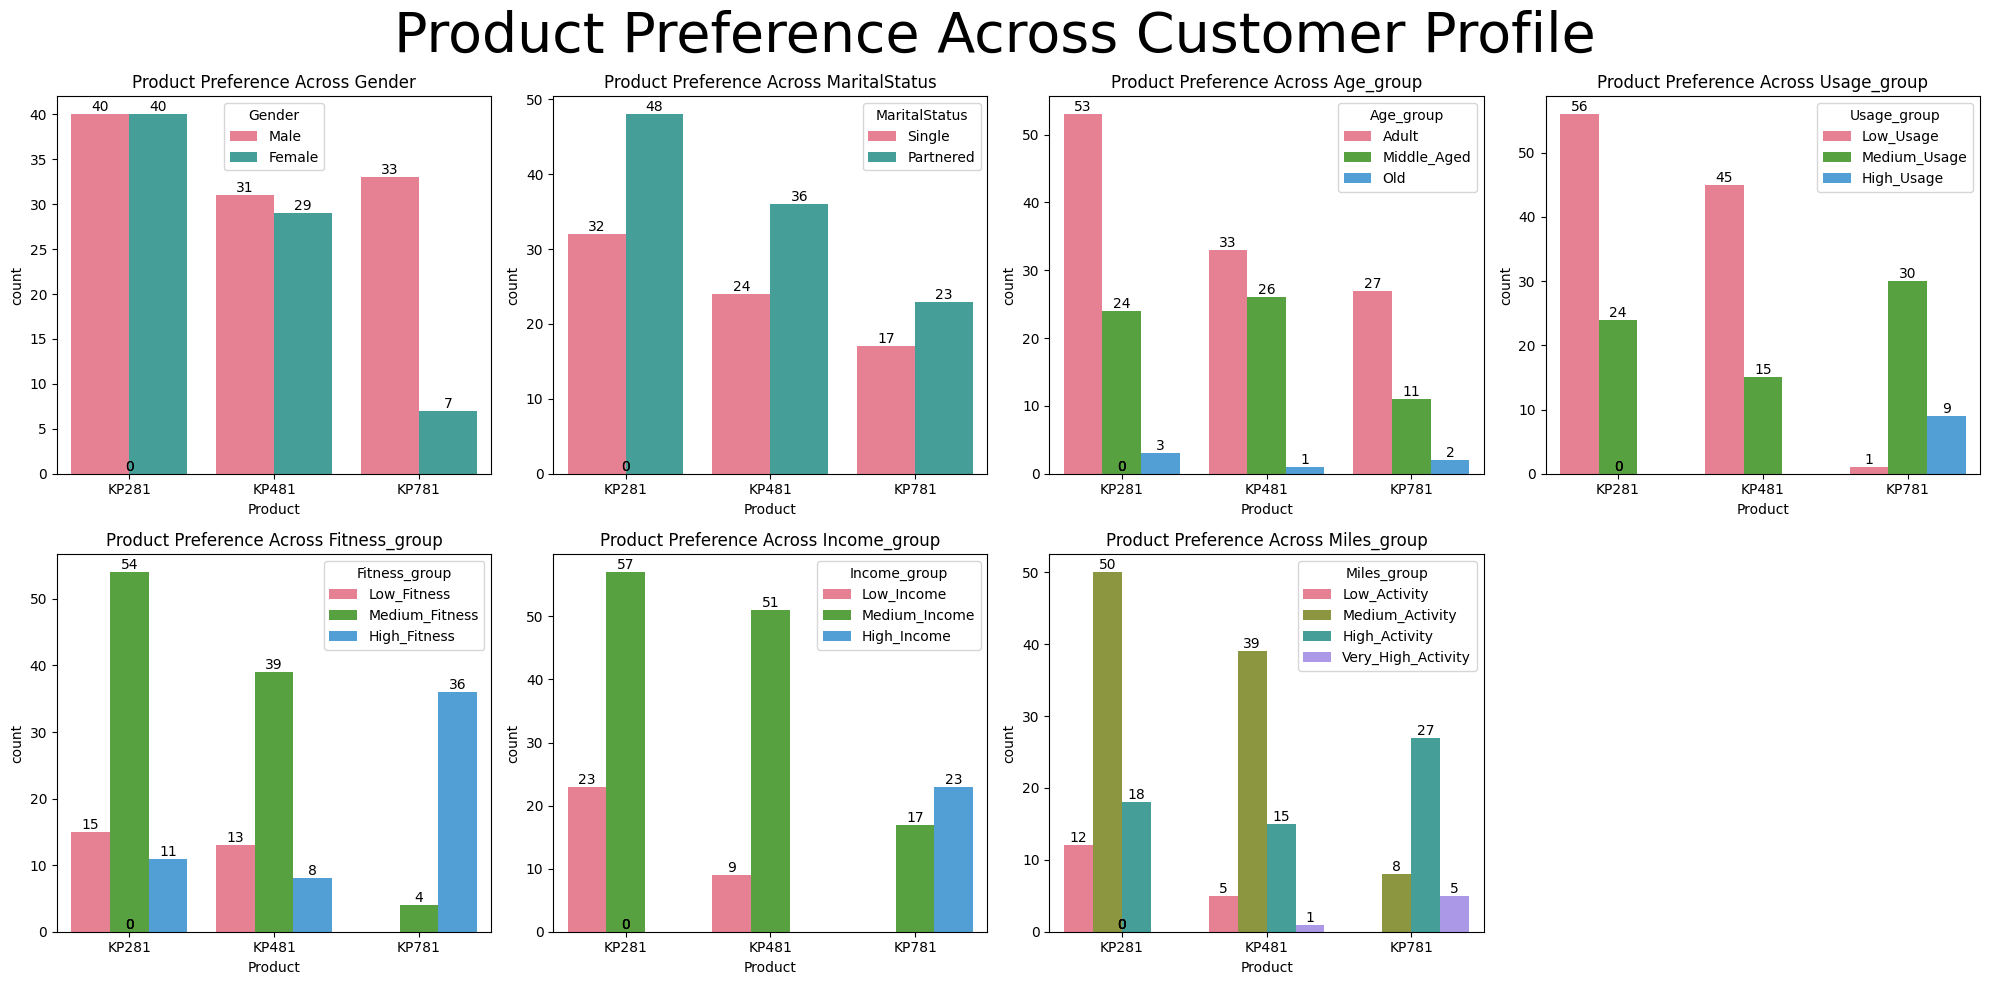

In [ ]:
cat_var = ["Gender", "MaritalStatus", "Age_group", "Usage_group", "Fitness_group","Income_group", "Miles_group"]

plt.figure(figsize=(20,10))

for i,j in enumerate(cat_var):
    plt.subplot(2,4,i+1)
    sns.countplot(x = "Product", hue = j , data = df, palette="husl")
    ax = plt.gca()
    text_format(ax)
    plt.title(f"Product Preference Across {j}")
plt.suptitle("Product Preference Across Customer Profile", fontsize = 40)
plt.tight_layout()
plt.show()

**Insights**:

---


*   Gender: KP781 is more popular with males as compared to females.


*   MaritalStatus: Married people mostly preffer KP281.
*   Age Group: Adults mostly prefer KP281 and middle aged people prefer KP481.


*   Usage Groups: If the customer is looking for high or medium usage they can go with KP781, for low usage they can go with KP281 or KP481.

*   Fitness Groups: If the customer is high fitness minded we can suggest KP781, for medium fitness minded customer we can suggest KP281 or KP481.
*   Income Groups: Medium income people mostly prefer KP281 then KP481, High income people mostly prefer KP781 and Low income people mostly prefer KP281.


*   Miles Groups: if the customer falls under medium miles group they can go with KP281, if Very high activity means go with KP781.









**Analysis on Product Preference Across Customer Profile**

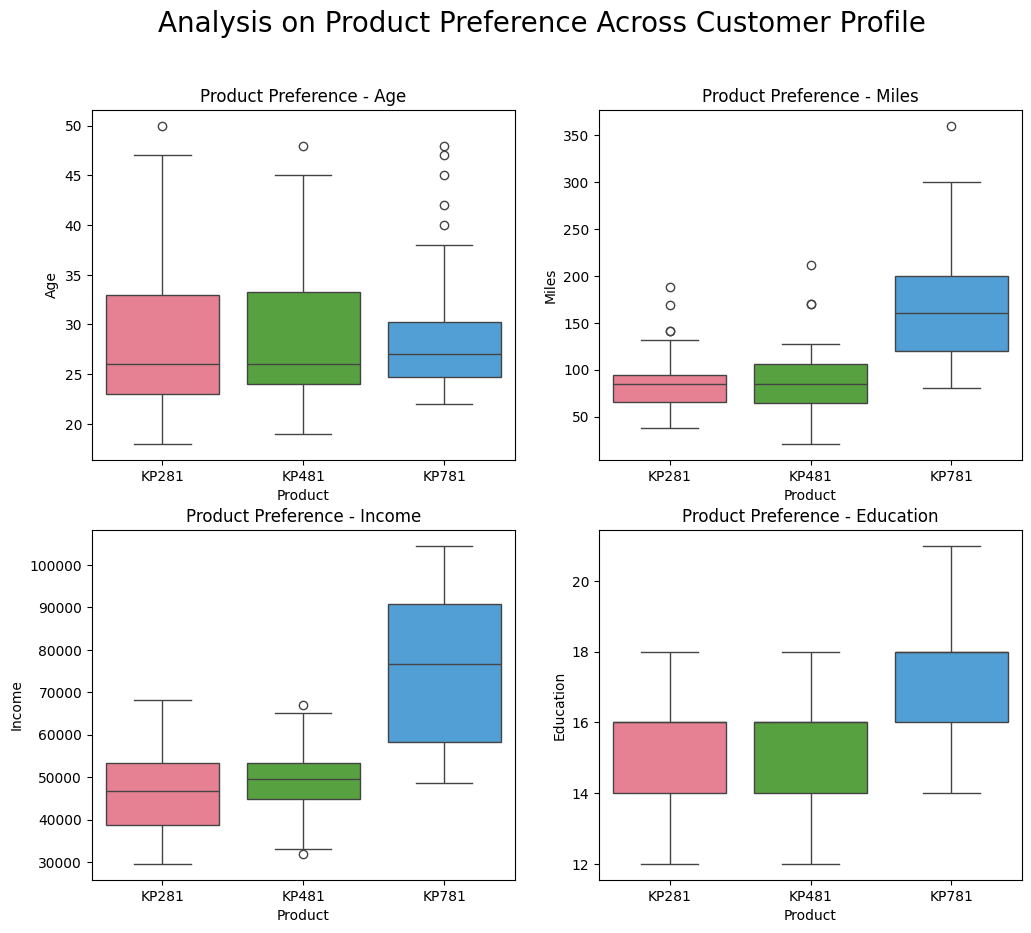

In [ ]:
num_var = ["Age","Miles","Income","Education"]
plt.figure(figsize= (12,10))
for i , j in enumerate(num_var):
  plt.subplot(2,2,i+1)
  sns.boxplot(x = "Product", y = j , data = df,palette = "husl")
  plt.title(f"Product Preference - {j}")
plt.suptitle("Analysis on Product Preference Across Customer Profile", fontsize = 20)
plt.show()

**Insights:**

---



*   Median Age of customers is higher for KP781 product as compared to other products.
*   The analysis suggests a clear preference for the KP781 treadmill model among customers with higher education as well as income levels.


*   KP781 treadmill is also prefered by customers who engage in running activities exceeding 150 miles per week.






**Gender wise Fitness_group, Usage_Group & Miles_group comparission**

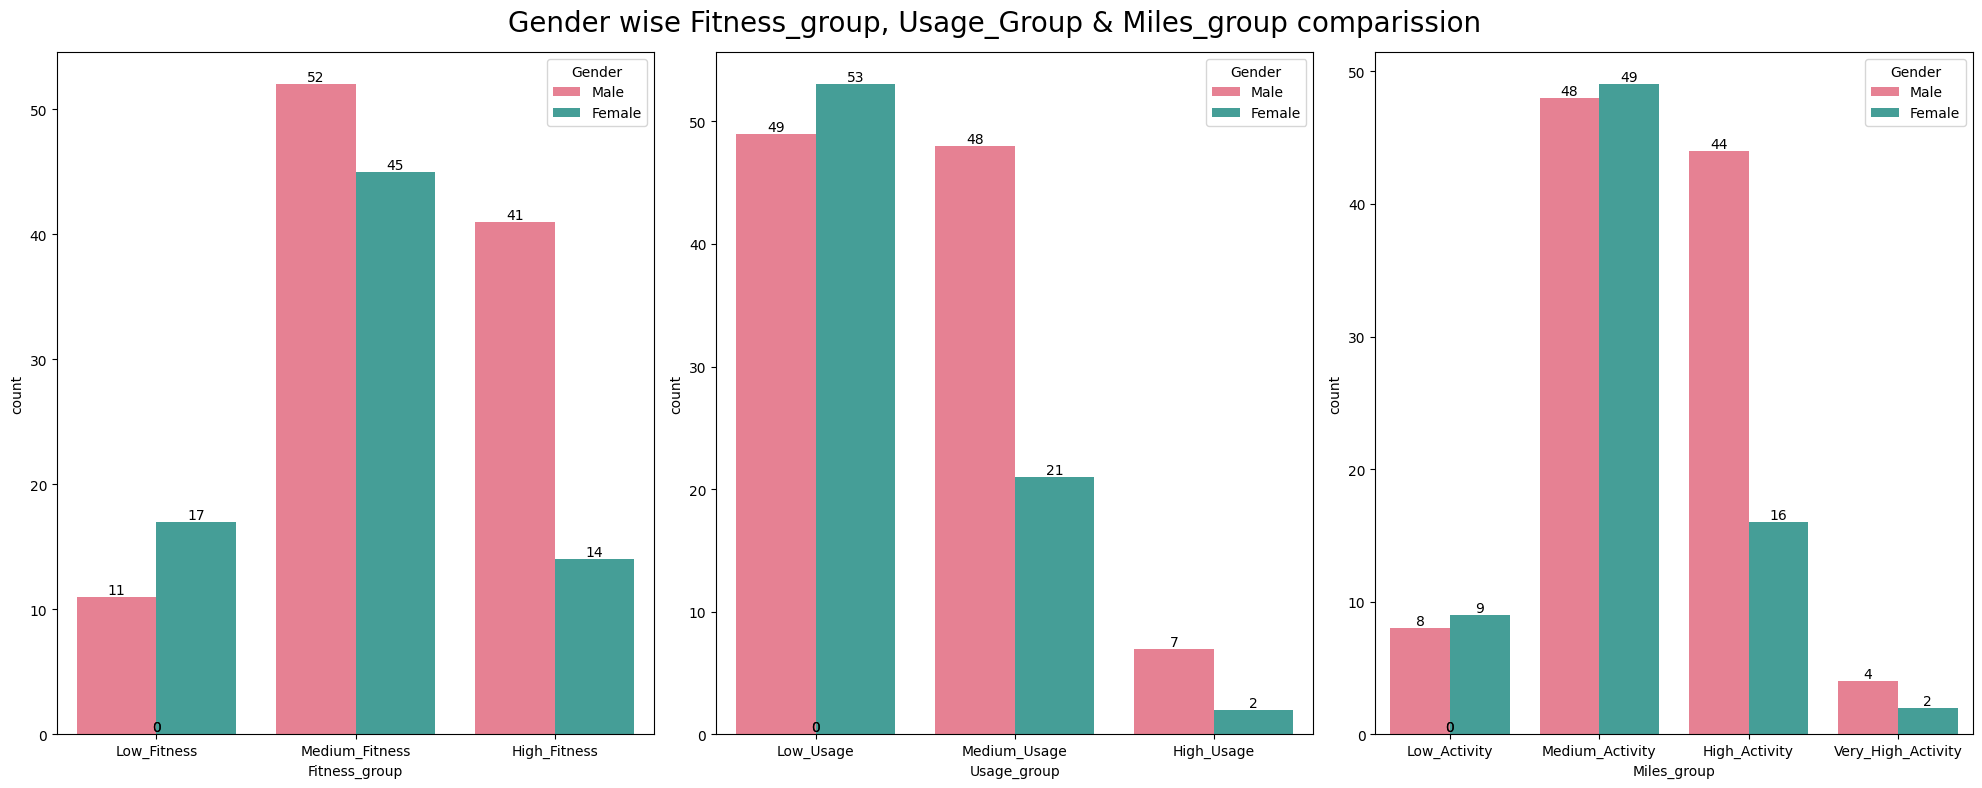

In [ ]:
plt.figure(figsize = (20,8))
plt.subplot(1,3,1)
sns.countplot(x = "Fitness_group",data = df , hue = "Gender", palette = "husl")
ax = plt.gca()
text_format(ax)
plt.subplot(1,3,2)
sns.countplot(x = "Usage_group" , data = df , hue = "Gender" , palette = "husl")
ax = plt.gca()
text_format(ax)
plt.subplot(1,3,3)
sns.countplot(x = "Miles_group" , data = df , hue = "Gender" , palette = "husl")
ax = plt.gca()
text_format(ax)
plt.suptitle("Gender wise Fitness_group, Usage_Group & Miles_group comparission", fontsize = 20)
plt.tight_layout()
plt.show()

**Insights:**

---



*   In Fitness Group: From the grapgh we can clearly see that maximum number of Males & Females comes under medium fitness group.
*   In Usage Group: Females count are higher than males under low usage group while Male gender outnumber Females under Medium Usage and high Usage group.

*  In Miles Group: Majority of Males and Females falls under Medium Activity group means they prefer 50 to 100 miles per week.





**Correlation Among Diffrent Factors**

In [ ]:
df1 = df.copy()
df1["Gender"].replace(["Male","Female"],[1,0],inplace = True)
df1["MaritalStatus"].replace(["Single","Partnered"],[0,1],inplace = True)
df1["Product"].replace(["KP281","KP481","KP781"],[0,1,2], inplace= True)
df1.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_group,Usage_group,Fitness_group,Income_group,Miles_group,Product_price
0,0,18,1,14,0,3,4,29562,112,Adult,Low_Usage,High_Fitness,Low_Income,High_Activity,1500
1,0,19,1,15,0,2,3,31836,75,Adult,Low_Usage,Medium_Fitness,Low_Income,Medium_Activity,1500
2,0,19,0,14,1,4,3,30699,66,Adult,Medium_Usage,Medium_Fitness,Low_Income,Medium_Activity,1500
3,0,19,1,12,0,3,3,32973,85,Adult,Low_Usage,Medium_Fitness,Low_Income,Medium_Activity,1500
4,0,20,1,13,1,4,2,35247,47,Adult,Medium_Usage,Low_Fitness,Low_Income,Low_Activity,1500


In [ ]:
df1.corr(numeric_only=True)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Product_price
Product,1.000000,0.032225,0.230653,0.495018,-0.017602,0.537447,0.594883,0.624168,0.571596,0.954425
Age,0.032225,1.000000,0.027544,0.280496,0.192152,0.015064,0.061105,0.513414,0.036618,0.029263
Gender,0.230653,0.027544,1.000000,0.094089,-0.018836,0.214424,0.254609,0.202053,0.217869,0.260842
Education,0.495018,0.280496,0.094089,1.000000,0.068569,0.395155,0.410581,0.625827,0.307284,0.563463
MaritalStatus,-0.017602,0.192152,-0.018836,0.068569,1.000000,-0.007786,-0.050751,0.150293,0.025639,-0.020309
Usage,0.537447,0.015064,0.214424,0.395155,-0.007786,1.000000,0.668606,0.519537,0.759130,0.623124
Fitness,0.594883,0.061105,0.254609,0.410581,-0.050751,0.668606,1.000000,0.535005,0.785702,0.696616
Income,0.624168,0.513414,0.202053,0.625827,0.150293,0.519537,0.535005,1.000000,0.543473,0.695847
Miles,0.571596,0.036618,0.217869,0.307284,0.025639,0.759130,0.785702,0.543473,1.000000,0.643923
Product_price,0.954425,0.029263,0.260842,0.563463,-0.020309,0.623124,0.696616,0.695847,0.643923,1.000000


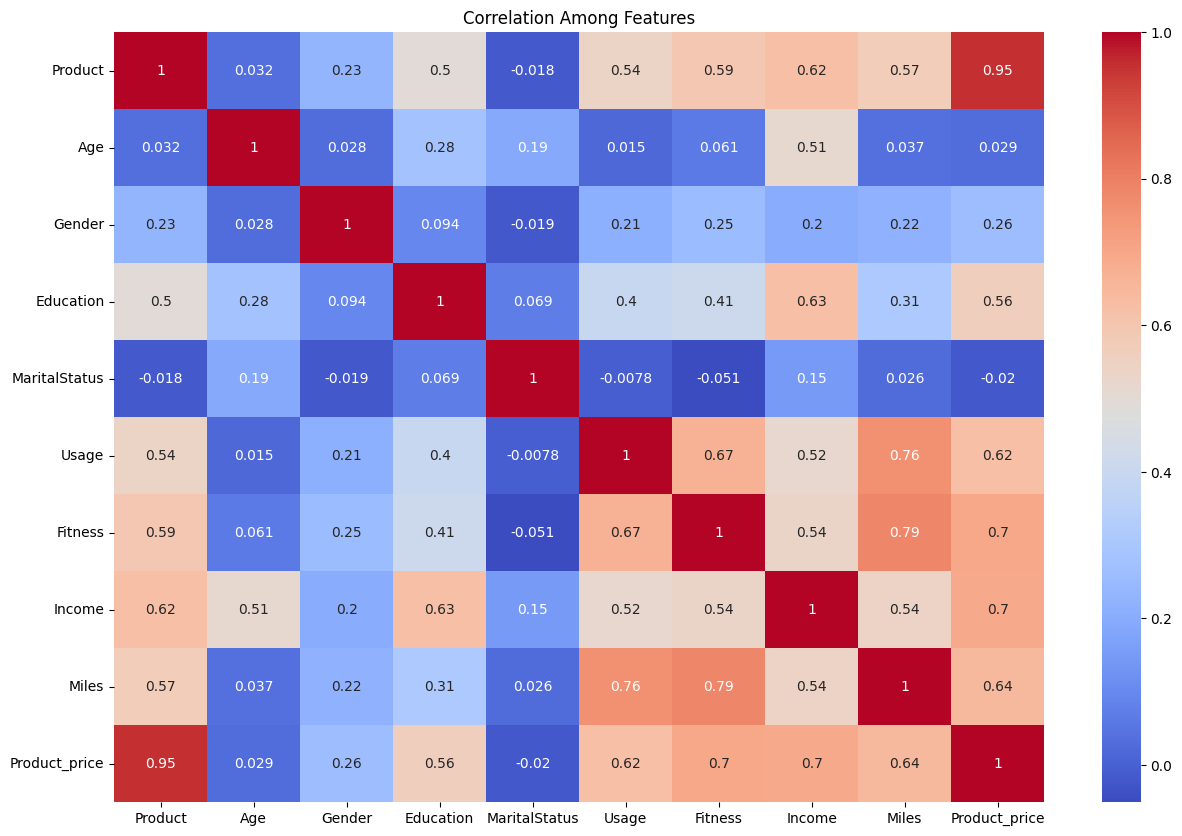

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df1.corr(numeric_only=True),annot =True, cmap="coolwarm")
plt.title("Correlation Among Features")
plt.show()

**Insights:**

---


*   Age & Income: A positive correlation is seen between age and income.
*   Education & Income: A positive correlation is seen between Education and income.


*   Education & Usage & Fitness: A positive correlation is seen between Education and income.
*   Fitness & Miles: A positive correlation is showing between Fitness & Miles.


*   Gender & MaritalStatus shows negative correlation
*   Fitness & MaritalStatus also shows negative correlation.







**Pair Plot Among Numerical Features**

<Figure size 2000x1000 with 0 Axes>

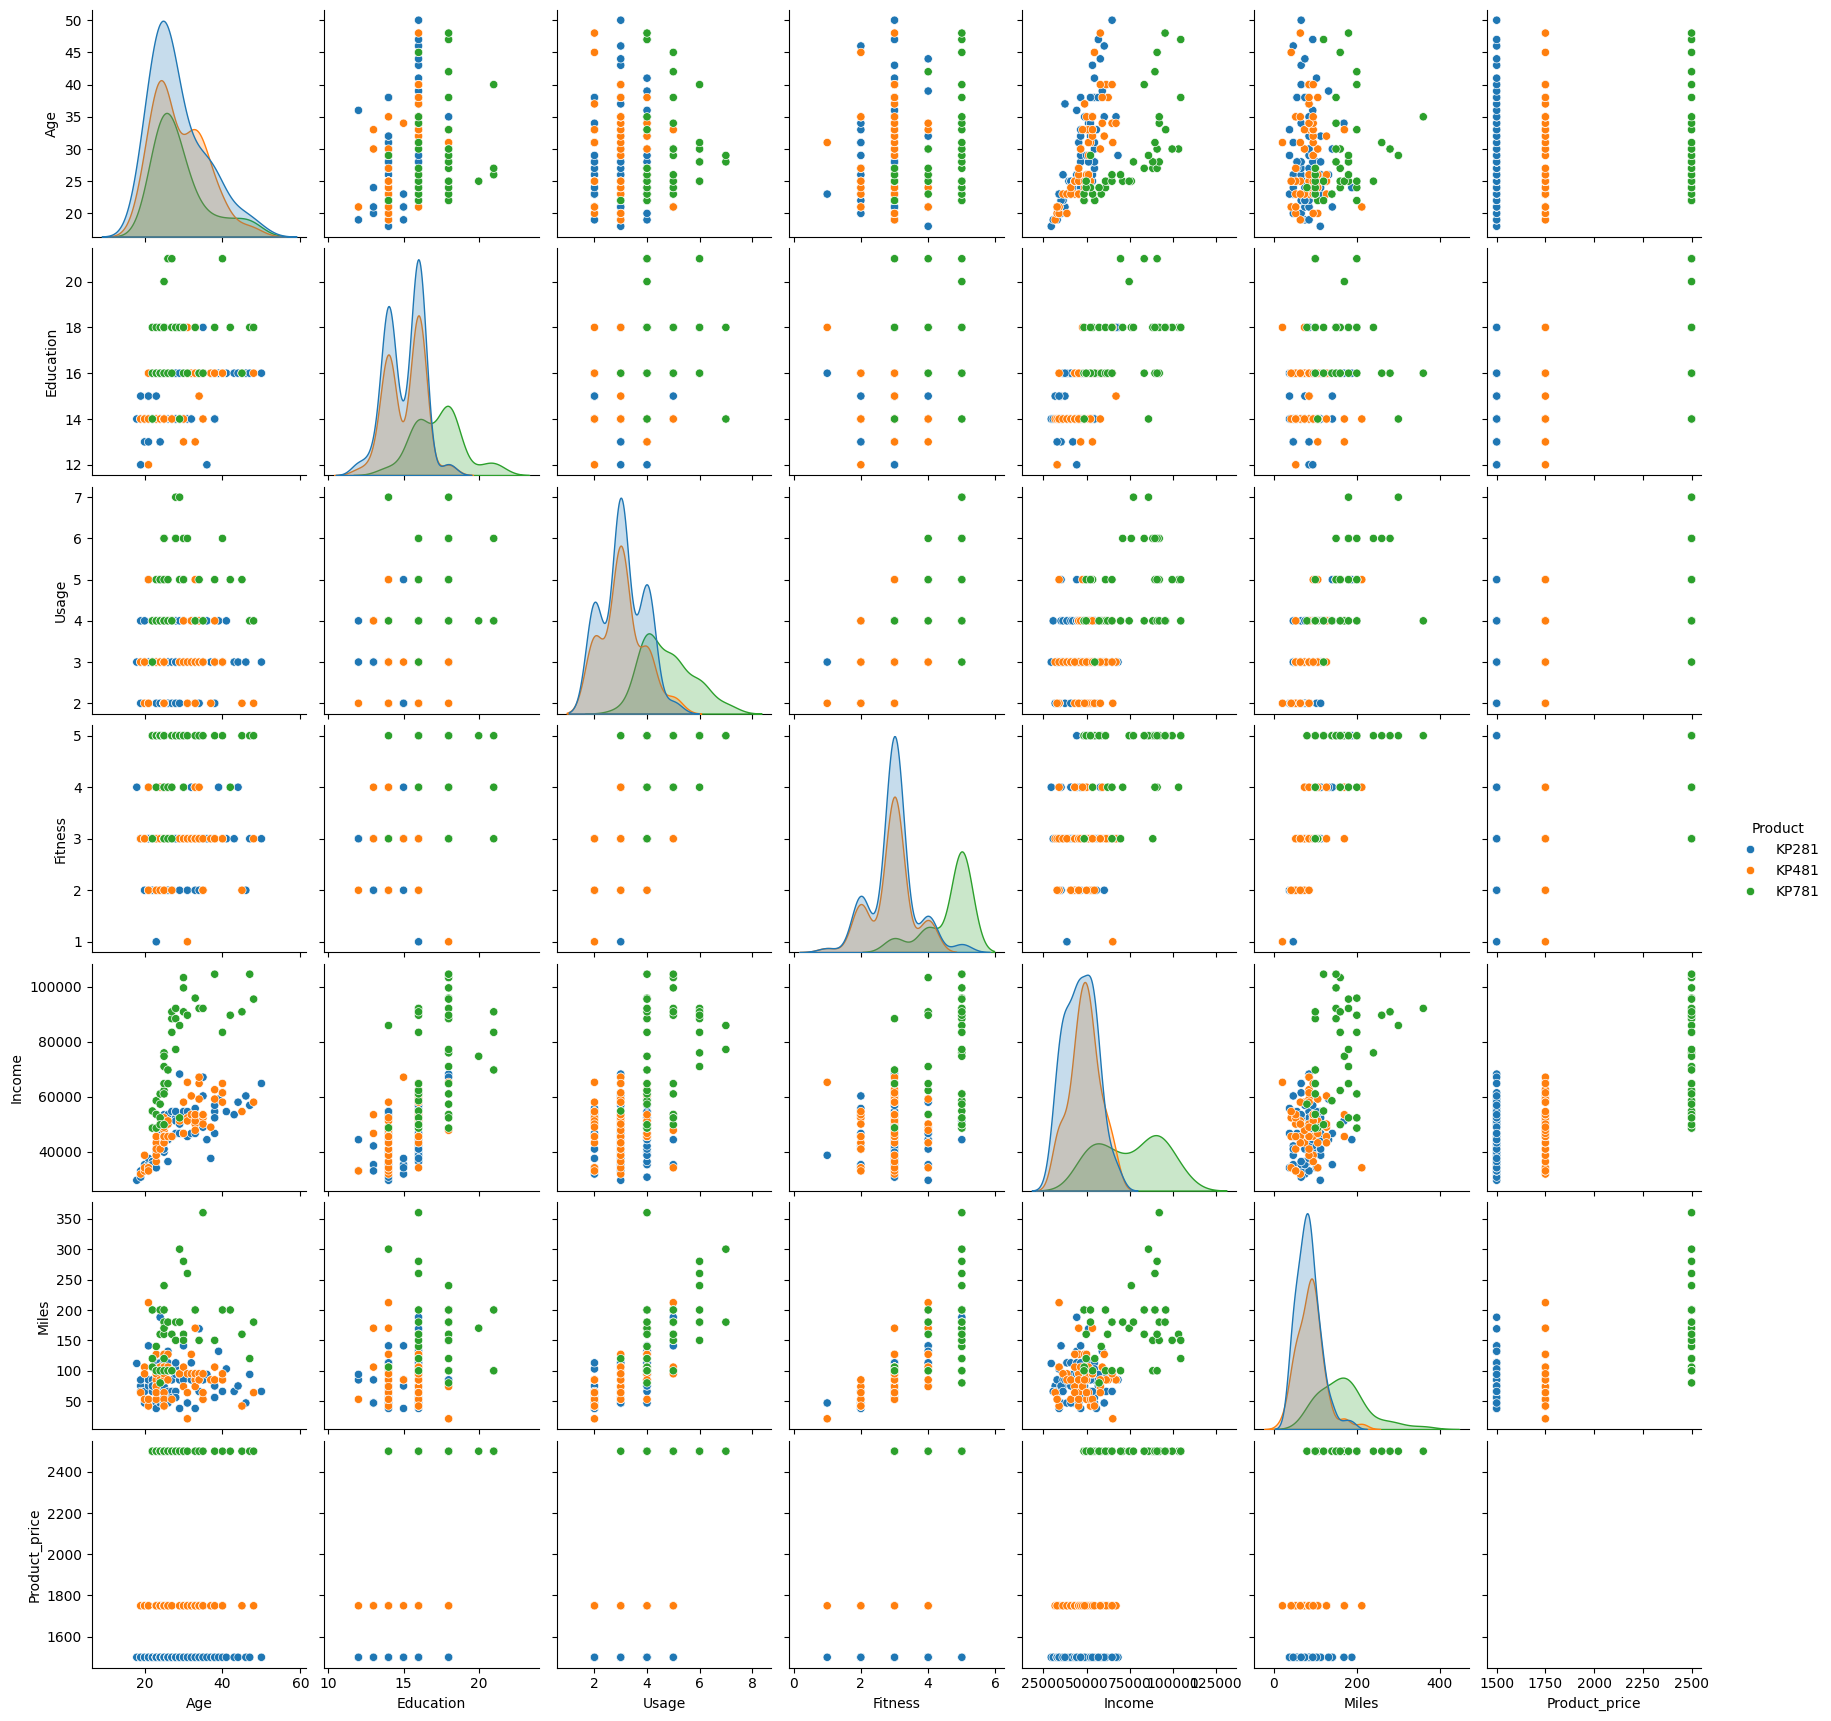

In [ ]:
plt.figure(figsize=(20,10))
sns.pairplot(df, hue="Product")
plt.show()

**Distribution Among Columns**

***Distribution of Product & Product Sales***

In [ ]:
Product_sales = df.groupby("Product")["Product_price"].sum().reset_index()
Product_sales

,Product,Product_price
0,KP281,120000
1,KP481,105000
2,KP781,100000


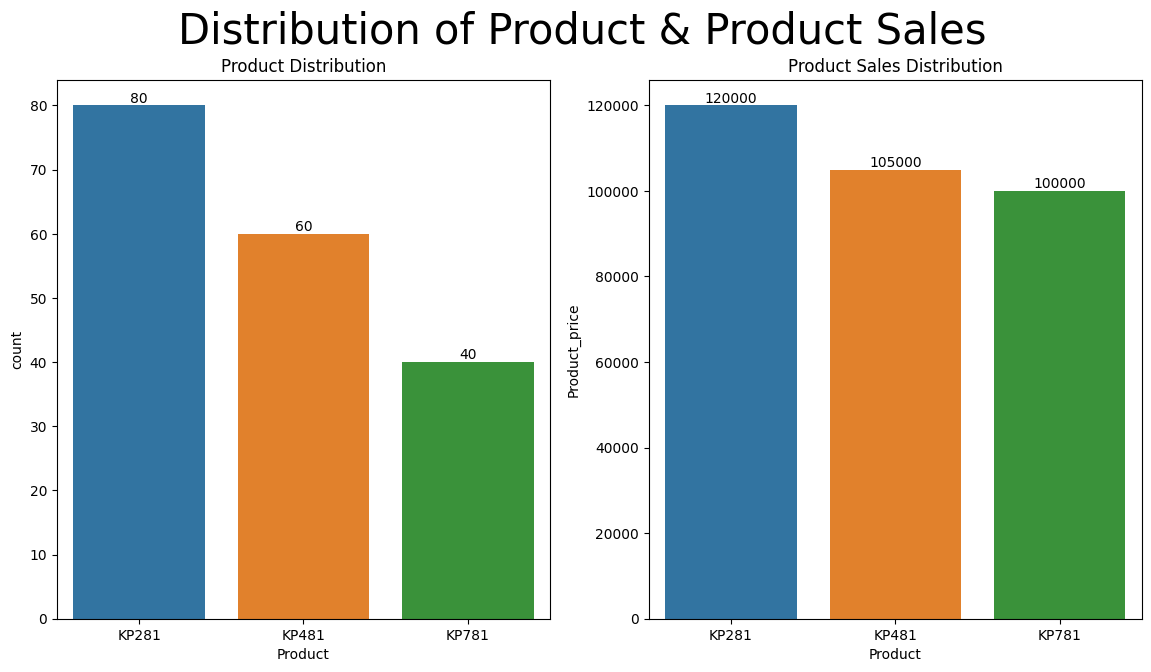

In [ ]:
plt.figure(figsize=(14,7))
plt.subplot(1,2,1)
sns.countplot(x= "Product", data = df, hue = "Product")
ax = plt.gca()
text_format(ax)
plt.title("Product Distribution")
plt.subplot(1,2,2)
sns.barplot(x = "Product", y = "Product_price", data = Product_sales, hue = "Product")
ax = plt.gca()
text_format(ax)
plt.title("Product Sales Distribution")
plt.suptitle("Distribution of Product & Product Sales", fontsize = 30)
plt.show()

**Insights:**

---



*   The KP281 treadmill, positioned as an entry-level model, leads in unit sales, followed by the mid-level KP481 and the advanced KP781 models.

*   all three treadmill models contribute to overall revenue generation, but KP281 produces highest revenue across product tiers. KP481 and KP781 almost contribute equally to the overall revenue.

*   Among the treadmill models, KP281 emerges as the most frequently purchased, while KP481 follows as the second most popular choice, with KP781 being the least preferred option.






**Gender & MaritalStatus Distribution**

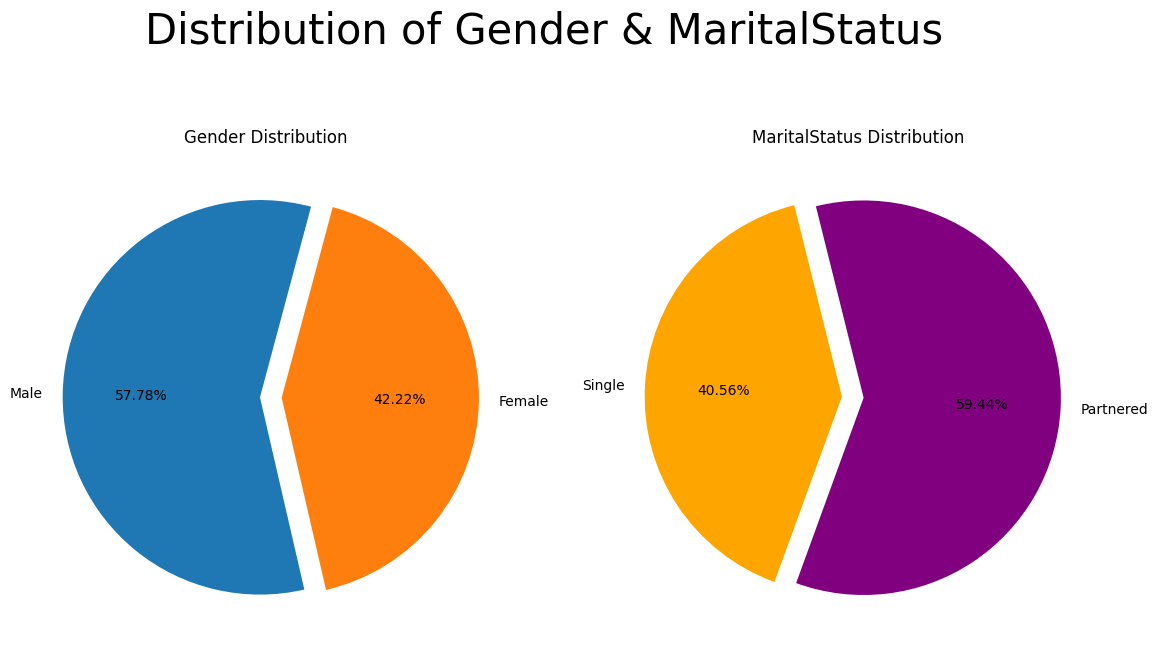

In [ ]:
plt.figure(figsize= (14,8))
plt.subplot(1,2,1)
labels = df["Gender"].value_counts().index
values = df["Gender"].value_counts().values
plt.pie(values, labels= labels, autopct= "%1.2f%%", explode = (0.03, 0.08), startangle=75)
plt.title("Gender Distribution")

plt.subplot(1,2,2)
labels = df["MaritalStatus"].value_counts().index
values = df["MaritalStatus"].value_counts().values
plt.pie(values, labels= labels, autopct= "%1.2f%%",colors= ["purple", "orange"],explode = (0.03, 0.08),startangle=250)
plt.title("MaritalStatus Distribution")
plt.suptitle("Distribution of Gender & MaritalStatus", fontsize = 30)
plt.show()

**Insights:**

---




*   There is a higher percentage or chance of males purchasing the products when compared to females.
*   There is a higher chance of Married purchasing the products as compared to Singles.




**Usage & Usage Group Distribution**

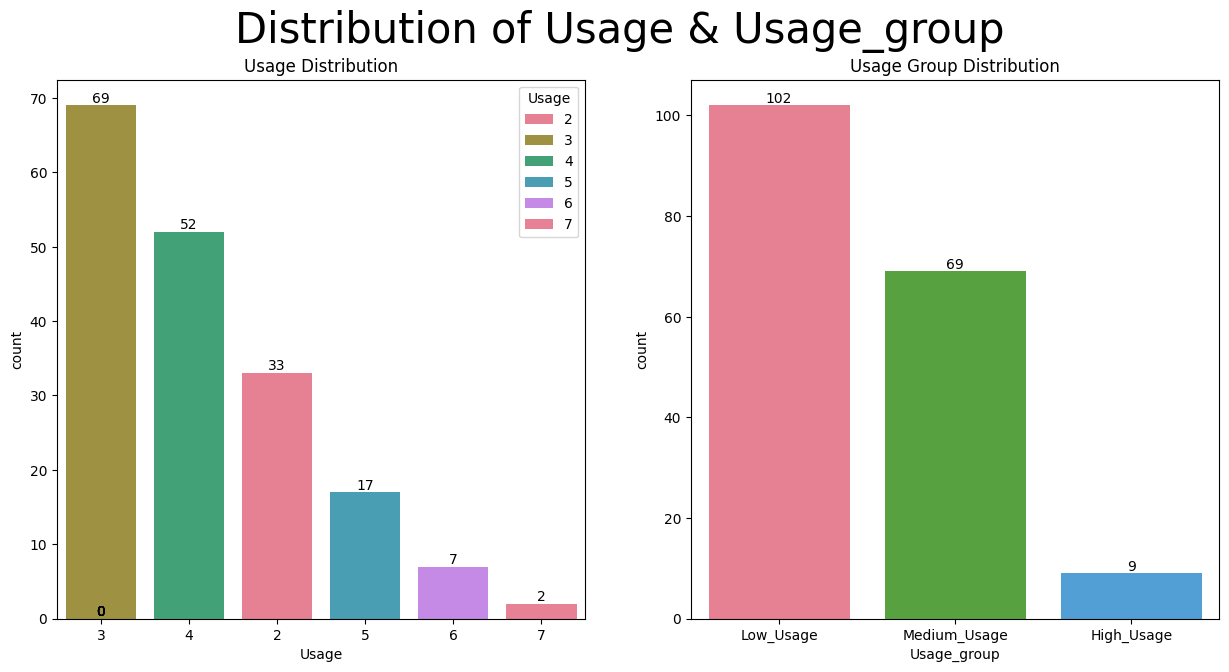

In [ ]:
plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
sns.countplot(x= "Usage", data = df, hue = "Usage", order = df["Usage"].value_counts().index, palette= "husl")
ax = plt.gca()
text_format(ax)
plt.title("Usage Distribution")
plt.subplot(1,2,2)
sns.countplot(x= "Usage_group", data = df, hue = "Usage_group", order = df["Usage_group"].value_counts().index, palette= "husl")
ax = plt.gca()
text_format(ax)
plt.title("Usage Group Distribution")
plt.suptitle("Distribution of Usage & Usage_group", fontsize = 30)
plt.show()

**Insights:**

---


*   Nearly 85% of customers intend to use the treadmill between 2 to 4 times per week, while only 15% plan to use it 5 times or more weekly.





**Fitness & Fitness Group Distribution**

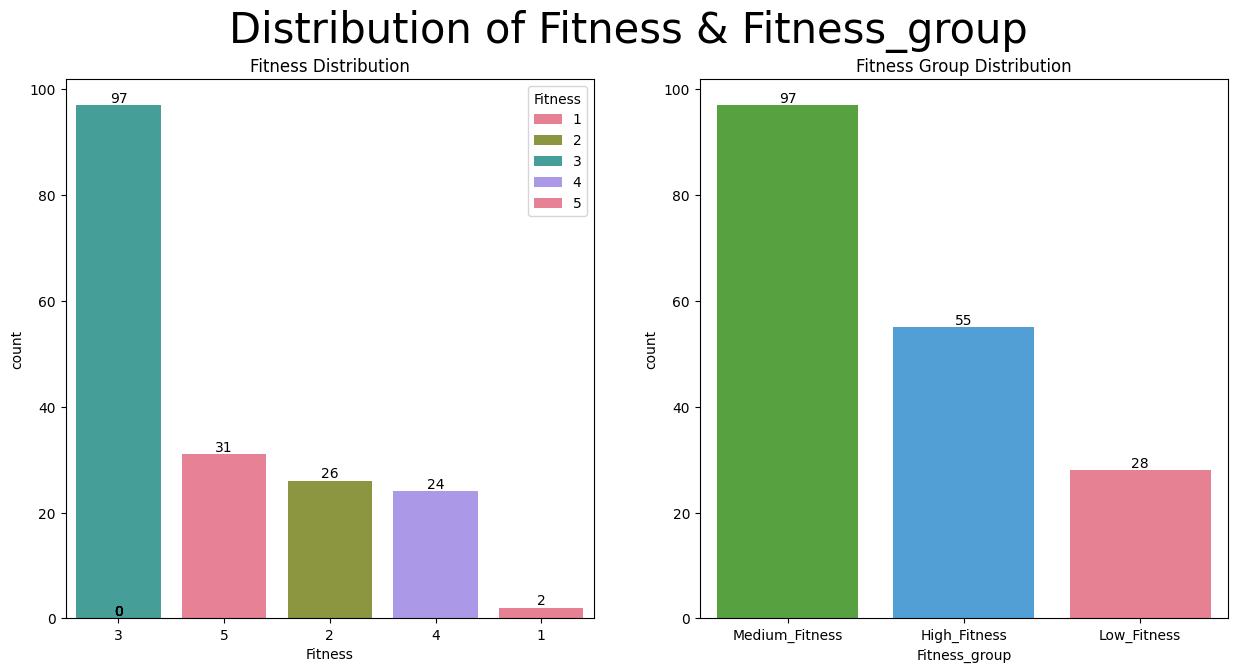

In [ ]:
plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
sns.countplot(x= "Fitness", data = df, hue = "Fitness", order = df["Fitness"].value_counts().index, palette= "husl")
ax = plt.gca()
text_format(ax)
plt.title("Fitness Distribution")
plt.subplot(1,2,2)
sns.countplot(x= "Fitness_group", data = df, hue = "Fitness_group", order = df["Fitness_group"].value_counts().index, palette= "husl")
ax = plt.gca()
text_format(ax)
plt.title("Fitness Group Distribution")
plt.suptitle("Distribution of Fitness & Fitness_group", fontsize = 30)
plt.show()

**Insights:**

---



*   The majority of participants (68.33%) falls within the "medium_fitness" category i.e fitness level 3.




**Outliersin Education Group & Education Distribution**

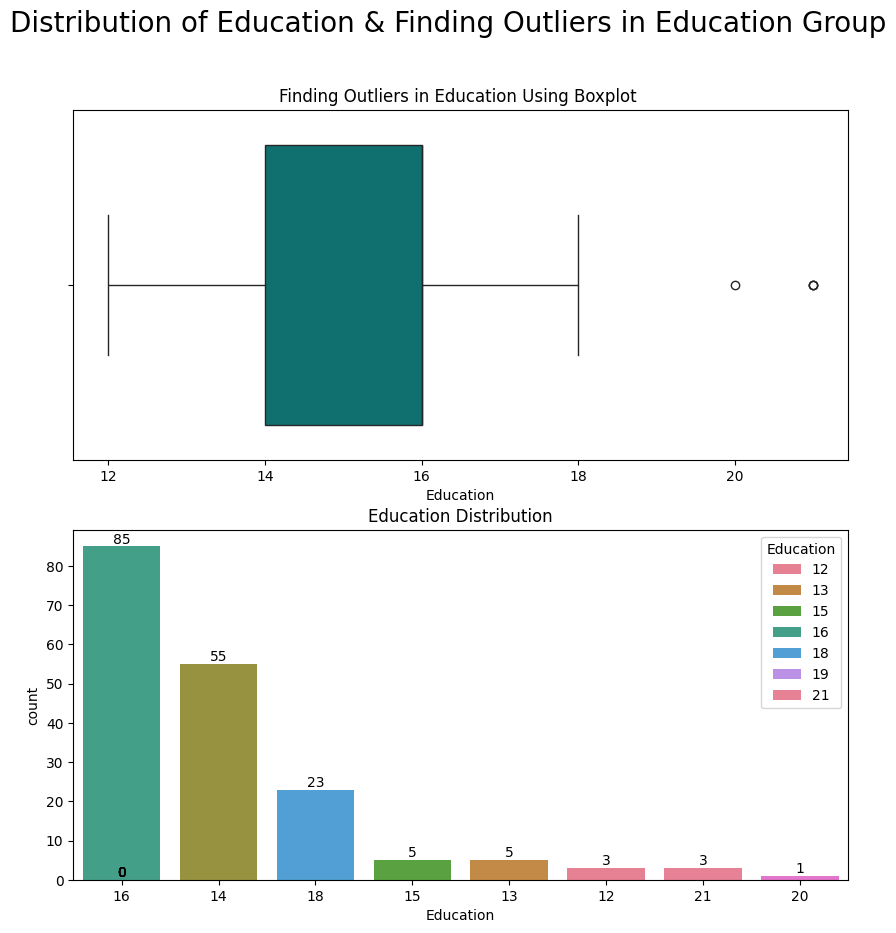

In [ ]:
plt.figure(figsize=(10,10))
plt.subplot(2,1,2)
sns.countplot(x= "Education", data = df, hue = "Education", order = df["Education"].value_counts().index, palette= "husl")
ax = plt.gca()
text_format(ax)
plt.title("Education Distribution")
plt.subplot(2,1,1)
sns.boxplot(x= "Education", data = df, color= "teal")
plt.title("Finding Outliers in Education Using Boxplot ")

plt.suptitle("Distribution of Education & Finding Outliers in Education Group", fontsize = 20)
plt.show()

**Insights:**

---



*   A significant majority of customers, approximately 91.67%, have education levels of 14 years or higher. This high proportion suggests a strong correlation between higher education and the purchase of aerofit items.



**Outliers in Income Group & Distribution**

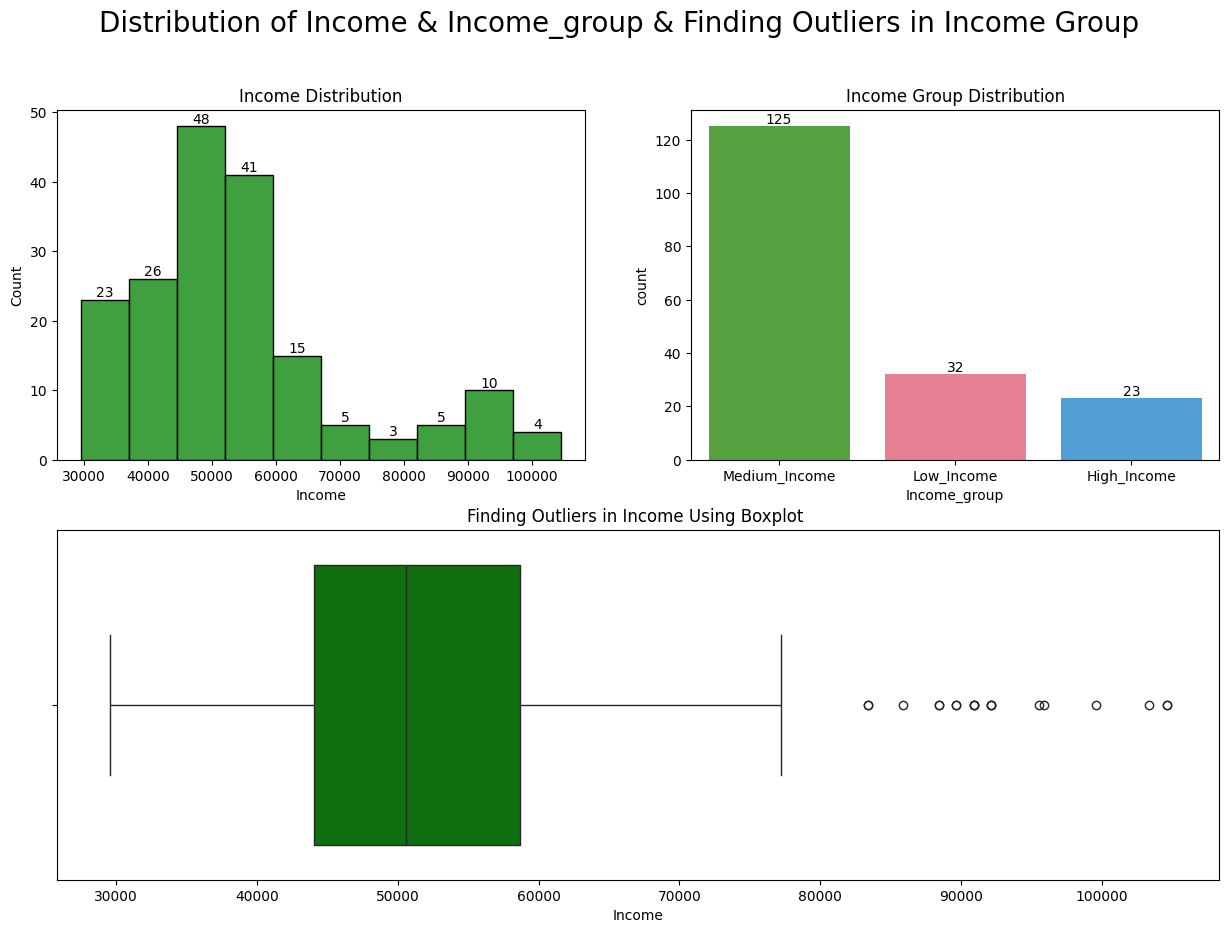

In [ ]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
sns.histplot(x= "Income",bins = 10,  data = df, kde = False, color= "green")
ax = plt.gca()
text_format(ax)
plt.title("Income Distribution")
plt.subplot(2,2,2)
sns.countplot(x= "Income_group", data = df, hue = "Income_group", order = df["Income_group"].value_counts().index, palette= "husl")
ax = plt.gca()
text_format(ax)
plt.title("Income Group Distribution")

plt.subplot(2,1,2)
sns.boxplot(x= "Income", data = df, color= "green")
plt.title("Finding Outliers in Income Using Boxplot ")

plt.suptitle("Distribution of Income & Income_group & Finding Outliers in Income Group", fontsize = 20)
plt.show()

**Insights:**

---



*   Medium income people mostly prefer KP281 then KP481, High income people mostly prefer KP781 and Low income people mostly prefer KP281.

*   The customers who comes Above income of USD 78,000 are outliers.



**Miles & Miles Group Distribution & Finding Outliers in Miles**

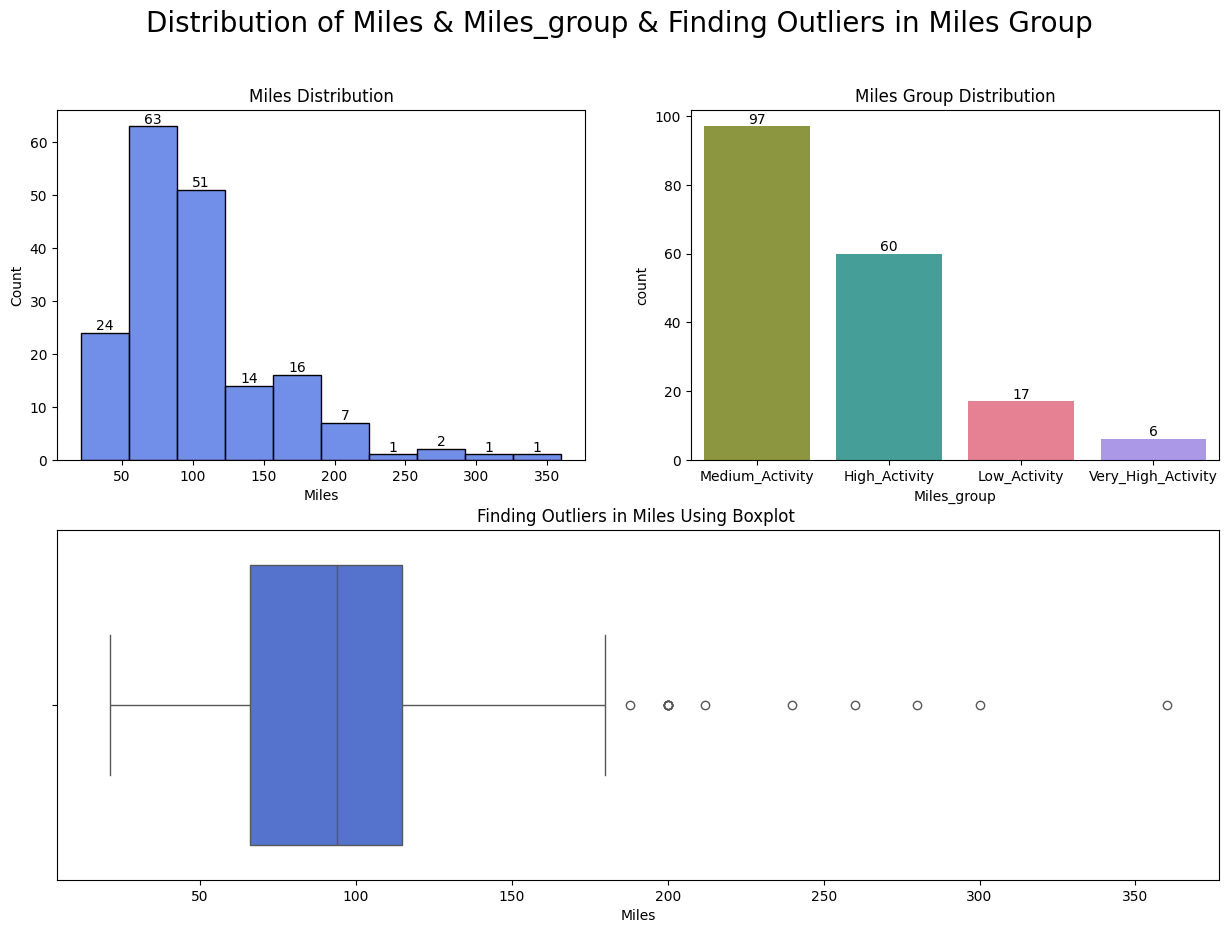

In [ ]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
sns.histplot(x= "Miles",bins = 10,  data = df, kde = False, color= "Royalblue")
ax = plt.gca()
text_format(ax)
plt.title("Miles Distribution")
plt.subplot(2,2,2)
sns.countplot(x= "Miles_group", data = df, hue = "Miles_group", order = df["Miles_group"].value_counts().index, palette= "husl")
ax = plt.gca()
text_format(ax)
plt.title("Miles Group Distribution")

plt.subplot(2,1,2)
sns.boxplot(x= "Miles", data = df, color= "RoyalBlue")
plt.title("Finding Outliers in Miles Using Boxplot ")

plt.suptitle("Distribution of Miles & Miles_group & Finding Outliers in Miles Group", fontsize = 20)
plt.show()

**Insights:**

---



*   If the customer falls under medium miles group they can go with KP281, if Very high activity means go with KP781.
*   Customers with over 180 miles are considered as outliers.



**Outliers in Age & Age Group Distribution**

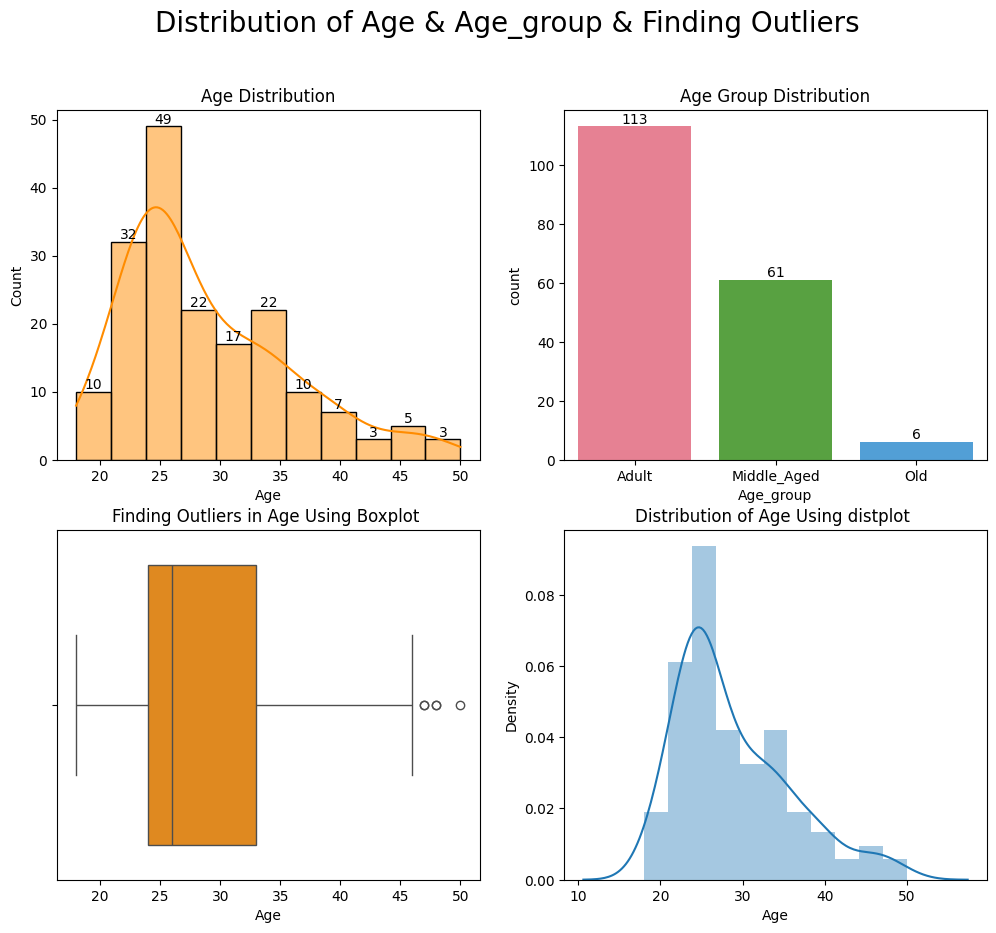

In [ ]:
plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
sns.histplot(x= "Age",bins = 11,  data = df, kde = True, color= "darkorange")
ax = plt.gca()
text_format(ax)
plt.title("Age Distribution")
plt.subplot(2,2,2)
sns.countplot(x= "Age_group", data = df, hue = "Age_group", order = df["Age_group"].value_counts().index, palette= "husl")
ax = plt.gca()
text_format(ax)
plt.title("Age Group Distribution")

plt.subplot(2,2,3)
sns.boxplot(x= "Age", data = df, color= "darkorange")
plt.title("Finding Outliers in Age Using Boxplot ")

plt.subplot(2,2,4)
sns.distplot(df["Age"], kde= True)
plt.title("Distribution of Age Using distplot ")

plt.suptitle("Distribution of Age & Age_group & Finding Outliers", fontsize = 20)
plt.show()

**Insights:**

---



*   Adults mostly prefer KP281 and middle aged people prefer KP481.

*   Above 46 years age customers are considered as outliers.



**Finding Range of each Attributes**

In [ ]:
# Checking the range of numerical attributes
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_columns:
    min_val = df[col].min()
    max_val = df[col].max()
    range_val = max_val - min_val
    print(f"Range of {col}: {min_val} to {max_val} (Range: {range_val})")

Range of Age: 18 to 50 (Range: 32)
Range of Education: 12 to 21 (Range: 9)
Range of Usage: 2 to 7 (Range: 5)
Range of Fitness: 1 to 5 (Range: 4)
Range of Income: 29562 to 104581 (Range: 75019)
Range of Miles: 21 to 360 (Range: 339)
Range of Product_price: 1500 to 2500 (Range: 1000)


**Contingency Table Creation**

In [ ]:
# Contingency table for Product vs Product_price
ct_Product_Product_price = pd.crosstab(df["Product"], df["Product_price"], margins= True, normalize= True)
print("Contingency Table for Product vs Product_price:")
print(ct_Product_Product_price)

Contingency Table for Product vs Product_price:
Product_price      1500      1750      2500       All
Product                                              
KP281          0.444444  0.000000  0.000000  0.444444
KP481          0.000000  0.333333  0.000000  0.333333
KP781          0.000000  0.000000  0.222222  0.222222
All            0.444444  0.333333  0.222222  1.000000


In [ ]:
# Contingency table for Product vs Education
ct_Product_Education = pd.crosstab(df["Education"],df["Product"], margins= True, normalize= True)
print("Contingency Table for Product vs Education:")
print(ct_Product_Education)

Contingency Table for Product vs Education:
Product       KP281     KP481     KP781       All
Education                                        
12         0.011111  0.005556  0.000000  0.016667
13         0.016667  0.011111  0.000000  0.027778
14         0.166667  0.127778  0.011111  0.305556
15         0.022222  0.005556  0.000000  0.027778
16         0.216667  0.172222  0.083333  0.472222
18         0.011111  0.011111  0.105556  0.127778
20         0.000000  0.000000  0.005556  0.005556
21         0.000000  0.000000  0.016667  0.016667
All        0.444444  0.333333  0.222222  1.000000


In [ ]:
# Contingency table for Product vs Gender
ct_Product_Gender = pd.crosstab(df["Product"], df["Gender"], margins= True, normalize= True)
print("Contingency Table for Product vs Gender:")
print(ct_Product_Gender)

Contingency Table for Product vs Gender:
Gender     Female      Male       All
Product                              
KP281    0.222222  0.222222  0.444444
KP481    0.161111  0.172222  0.333333
KP781    0.038889  0.183333  0.222222
All      0.422222  0.577778  1.000000


In [ ]:
# Contingency table for Product vs MaritalStatus
ct_Product_MaritalStatus = pd.crosstab(df["Product"], df["MaritalStatus"], margins= True, normalize= True)
print("Contingency Table for Product vs MaritalStatus:")
print(ct_Product_MaritalStatus)

Contingency Table for Product vs MaritalStatus:
MaritalStatus  Partnered    Single       All
Product                                     
KP281           0.266667  0.177778  0.444444
KP481           0.200000  0.133333  0.333333
KP781           0.127778  0.094444  0.222222
All             0.594444  0.405556  1.000000


In [ ]:
# Contingency table for Product vs Usage
ct_Product_Usage = pd.crosstab(df["Product"], df["Usage"], margins= True, normalize= True)
print("Contingency Table for Product vs Usage:")
print(ct_Product_Usage)

Contingency Table for Product vs Usage:
Usage           2         3         4         5         6         7       All
Product                                                                      
KP281    0.105556  0.205556  0.122222  0.011111  0.000000  0.000000  0.444444
KP481    0.077778  0.172222  0.066667  0.016667  0.000000  0.000000  0.333333
KP781    0.000000  0.005556  0.100000  0.066667  0.038889  0.011111  0.222222
All      0.183333  0.383333  0.288889  0.094444  0.038889  0.011111  1.000000


In [ ]:
# Contingency table for Product vs Fitness
ct_Product_Fitness = pd.crosstab(df["Product"], df["Fitness"], margins= True, normalize= True)
print("Contingency Table for Product vs Fitness:")
print(ct_Product_Fitness)

Contingency Table for Product vs Fitness:
Fitness         1         2         3         4         5       All
Product                                                            
KP281    0.005556  0.077778  0.300000  0.050000  0.011111  0.444444
KP481    0.005556  0.066667  0.216667  0.044444  0.000000  0.333333
KP781    0.000000  0.000000  0.022222  0.038889  0.161111  0.222222
All      0.011111  0.144444  0.538889  0.133333  0.172222  1.000000


In [ ]:
# Contingency table for Product vs Age_group
ct_Product_Age_group = pd.crosstab(df["Product"], df["Age_group"], margins= True, normalize= True)
print("Contingency Table for Product vs Age_group:")
print(ct_Product_Age_group)

Contingency Table for Product vs Age_group:
Age_group     Adult  Middle_Aged       Old       All
Product                                             
KP281      0.294444     0.133333  0.016667  0.444444
KP481      0.183333     0.144444  0.005556  0.333333
KP781      0.150000     0.061111  0.011111  0.222222
All        0.627778     0.338889  0.033333  1.000000


In [ ]:
# Contingency table for Product vs Income_group
ct_Product_Income_group = pd.crosstab(df["Product"], df["Income_group"], margins= True, normalize= True)
print("Contingency Table for Product vs Income_group:")
print(ct_Product_Income_group)

Contingency Table for Product vs Income_group:
Income_group  Low_Income  Medium_Income  High_Income       All
Product                                                       
KP281           0.127778       0.316667     0.000000  0.444444
KP481           0.050000       0.283333     0.000000  0.333333
KP781           0.000000       0.094444     0.127778  0.222222
All             0.177778       0.694444     0.127778  1.000000


In [ ]:
# Contingency table for Product vs Miles_group
ct_Product_Miles_group = pd.crosstab( df["Miles_group"],df["Product"], margins= True, normalize= True)
print("Contingency Table for Product vs Miles_group:")
print(ct_Product_Miles_group)

Contingency Table for Product vs Miles_group:
Product                KP281     KP481     KP781       All
Miles_group                                               
Low_Activity        0.066667  0.027778  0.000000  0.094444
Medium_Activity     0.277778  0.216667  0.044444  0.538889
High_Activity       0.100000  0.083333  0.150000  0.333333
Very_High_Activity  0.000000  0.005556  0.027778  0.033333
All                 0.444444  0.333333  0.222222  1.000000


**Insights:**

---



*   **Education**
    *   Highest Education Level (16 years):

            1. Probability of purchase: 47%
            2. Preferred models: KP281 (22%), KP481 (17%), KP781 (8%).

    *   Moderate Education Level (14 years):

            1. Probability of purchase: 31%.
            2. Preferred models: KP281 (17%), KP481 (13%), KP781 (1%).


*   **Gender**
    *   Females:

            1. Probability of purchase: 42%.
            2. Preferred models: KP281 (22%), KP481 (16%), KP781 (4%).

    *   Males:

            1. Probability of purchase: 58%.
            2. Preferred models: KP281 (22%), KP481 (17%), KP781 (18%).



*   **Marital Status**
    *   Partnered:

            1. Probability of purchase: 59%.
            2. Preferred models: KP281 (27%), KP481 (20%), KP781 (13%).

    *   Single:

            1. Probability of purchase: 41%.
            2. Preferred models: KP281 (18%), KP481 (13%), KP781 (9%).



*   **Usage**
    *   High Usage (3 times per week):

            1. Probability of purchase: 38%.
            2. Preferred models: KP281 (21%), KP481 (17%), KP781 (1%).



    *   Moderate Usage (4 times per week):

            1. Probability of purchase: 29%.
            2. Preferred models: KP281 (12%), KP481 (7%), KP781 (10%).

*   **Fitness**
    *   Moderate Fitness Level (3):

            1. Probability of purchase: 54%.
            2. Preferred models: KP281 (30%), KP481 (22%), KP781 (2%).

    *   High Fitness Level (5):

            1. Probability of purchase: 17%.
            2. Preferred models: KP281 (1%), KP481 (0%), KP781 (16%).


*   **Age Group**
    *   Adults:

            1. Probability of purchase: 63%
            2. Preferred models: KP281 (29%), KP481 (18%), KP781 (15%).

    *   Middle-Aged:

            1. Probability of purchase: 34%.
            2. Preferred models: KP281 (13%), KP481 (14%), KP781 (6%).

*   **Income Group**
    *   Low Income:

            1. Probability of purchase: 18%.
            2. Preferred models: KP281 (13%), KP481 (5%), KP781 (0%).

    *   Moderate Income:

            1. Probability of purchase: 68%.
            2. Preferred models: KP281 (31%), KP481 (28%), KP781 (9%).


    *   High Income:

            1. Probability of purchase: 13%.
            2. Preferred models: KP281 (0%), KP481 (0%), KP781 (13%).



**Marginal Probability**

In [ ]:
#Marginal Probabilities for Product
marginal_Product = ct_Product_Product_price.sum(axis=1) / len(df)
print("\nMarginal Probabilities for Product:")
print(marginal_Product)


Marginal Probabilities for Product:
Product
KP281    0.004938
KP481    0.003704
KP781    0.002469
All      0.011111
dtype: float64


In [ ]:
#Marginal Probabilities for Gender
marginal_Gender = ct_Product_Gender.sum(axis=0) / len(df)
print("\nMarginal Probabilities for Gender:")
print(marginal_Gender)


Marginal Probabilities for Gender:
Gender
Female    0.004691
Male      0.006420
All       0.011111
dtype: float64


In [ ]:
#Marginal Probabilities for Age_group
marginal_Age_group = ct_Product_Age_group.sum(axis=0) / len(df)
print("\nMarginal Probabilities for Age_group:")
print(marginal_Age_group)


Marginal Probabilities for Age_group:
Age_group
Adult          0.006975
Middle_Aged    0.003765
Old            0.000370
All            0.011111
dtype: float64


In [ ]:
#Marginal Probabilities for Income_group
marginal_Income_group = ct_Product_Income_group.sum(axis=0) / len(df)
print("\nMarginal Probabilities for Income_group:")
print(marginal_Income_group)


Marginal Probabilities for Income_group:
Income_group
Low_Income       0.001975
Medium_Income    0.007716
High_Income      0.001420
All              0.011111
dtype: float64


**Conditional Probability**

In [ ]:
# Conditional probability of Gender given Product (P(Gender|Product))
conditional_Gender_given_Product = ct_Product_Gender.div(ct_Product_Gender.sum(axis=1), axis=0)
print("\nConditional Probability of Gender given Product:")
print(conditional_Gender_given_Product)


Conditional Probability of Gender given Product:
Gender     Female      Male  All
Product                         
KP281    0.250000  0.250000  0.5
KP481    0.241667  0.258333  0.5
KP781    0.087500  0.412500  0.5
All      0.211111  0.288889  0.5


In [ ]:
# Conditional probability of Product given Gender (P(Product|Gender))
conditional_Product_given_Gender = ct_Product_Gender.div(ct_Product_Gender.sum(axis=0), axis=1)
print("\nConditional Probability of Product given Gender:")
print(conditional_Product_given_Gender)


Conditional Probability of Product given Gender:
Gender     Female      Male       All
Product                              
KP281    0.263158  0.192308  0.222222
KP481    0.190789  0.149038  0.166667
KP781    0.046053  0.158654  0.111111
All      0.500000  0.500000  0.500000


In [ ]:
# Conditional probability of Product given Age_group (P(Product|Age_group))
conditional_Product_given_Age_group = ct_Product_Age_group.div(ct_Product_Age_group.sum(axis=0), axis=1)
print("\nConditional Probability of Product given Age_group:")
print(conditional_Product_given_Age_group)


Conditional Probability of Product given Age_group:
Age_group     Adult  Middle_Aged       Old       All
Product                                             
KP281      0.234513     0.196721  0.250000  0.222222
KP481      0.146018     0.213115  0.083333  0.166667
KP781      0.119469     0.090164  0.166667  0.111111
All        0.500000     0.500000  0.500000  0.500000


In [ ]:
# Conditional probability of Product given Income_group (P(Product|Income_group))
conditional_Product_given_Income_group = ct_Product_Income_group.div(ct_Product_Income_group.sum(axis=0), axis=1)
print("\nConditional Probability of Product given Income_group:")
print(conditional_Product_given_Income_group)


Conditional Probability of Product given Income_group:
Income_group  Low_Income  Medium_Income  High_Income       All
Product                                                       
KP281           0.359375          0.228          0.0  0.222222
KP481           0.140625          0.204          0.0  0.166667
KP781           0.000000          0.068          0.5  0.111111
All             0.500000          0.500          0.5  0.500000


**Customer Profiling of Each Aerofit Product**

**Customer Profile for KP281 Treadmill:**

---




*   Gender: the customers using KP281 are 50% male and 50% female
*   Age Group: The customers using KP281 are 66.25% adults, 30% middle aged and 3.75% old people.


*   MaritalStatus: The customers using KP281 are 60% married and 40% single.

*   Usage Groups: The customers using KP281 are 70% low usage people and 30% medium usage people.

*   Fitness Groups: The customers using KP281 are 67.5% medium fitness mind people, 18.75% low fitness minded people and 13.75% high fitness minded people.

*   Income Groups: The customers using KP281 are 71.25% medium income people and 28.75% low income people.
*   Miles Groups: The customers using KP281 are 62.5% medium activity people, 22.5% high activity people and 15% low activity people.


*   Sales: 37% sales from KP281.





**Customer Profile for KP481 Treadmill:**


---



*   Gender: the customers using KP481 are 51.7% male and 48.3% female .


*   Age Group: The customers using KP481 are 55% adults, 43.3% middle aged and 1.7% old people.


*   MaritalStatus: The customers using KP481 are 60% married and 40% single.

*   Usage Groups: The customers using KP481 are 75% low usage people, 25% medium usage people.
*   Fitness Groups: The customers using KP481 are 65% medium fitness minded people, 21.7% low fitness minded people and 13.3% high fitness minded people.


*   Income Groups: The customers using KP481 are 85% medium income people and 15% low income people.


*   Miles Groups: The customers using KP481 are 65% medium activity people, 25% high activity people, 8.3% low activity people and 1.7% very high activity people.


*   Sales: 32.3% sales from KP481.



**Customer Profile for KP781 Treadmill:**

---



*   Gender: the customers using KP781 are 82.5% male and 17.5% female .

*   Age Group: The customers using KP781 are 67.5% adults, 27.5% middle aged and 5% old people.


*   MaritalStatus: The customers using KP781 are 57.5% married and 42.5% single.


*   Usage Groups: The customers using KP781 are 75% medium usage people, 22.5% high usage people and 2.5% low usage people.


*   Fitness Groups: The customers using KP781 are 90% high fitness minded people and 10% medium fitness minded people.

*   Income Groups: The customers using KP781 are 57.5% high income people and 42.5% medium income people.



*   Miles Groups: The customers using KP781 are 67.5% high activity people, 20% medium activity people and 12.5% very high activity people.



*   Sales: 30.7% sales from KP781.






**Business Insights / Impact on Business**


*   **Comments on Relationship Between Variables**


    *  **Age vs Income:** There is a positive correlation between age and income, suggesting that older customers tend to have higher incomes and may be more likely to purchase premium products like KP283.

    *  **Gender vs Product Preference:** Female customers show a stronger preference for KP281, while male customers are more evenly distributed across all products.

    *  **Usage Group vs Fitness Group:** There is no strong relationship between usage group and fitness group, suggesting that these factors do not significantly influence product preference.



*   **Comments on the Distribution of Variables**

    *   **Gender Distribution:** The distribution shows a slight imbalance with more male customers than female customers. However, female customers have a higher preference for KP281.


    *   **Age Group Distribution:** The distribution is skewed towards younger age groups, indicating that AeroFit's marketing efforts should focus on this demographic.

    *   **Income Group Distribution:** The distribution indicates that customers with higher incomes are more likely to purchase AeroFit products.



*   **Comments on the Range of Attributes**

    *   **Age Group:** The age range of customers is between 20 and 60 years, with a majority in the younger age groups. This suggests that AeroFit's products are more appealing to younger demographics.


    *   **Income Group:** The income range varies widely, but there is a higher concentration of customers in the middle to high-income brackets. This indicates that AeroFit's products are priced attractively for this segment.

    *   **Product Preference:** The range of product preferences shows that KP281 is the most popular product, followed by KP282 and then KP283.











**Recommendations**


**Actionable Recommendations for the AeroFit Business by the above analysis:**

---




*   **Gender-Specific Campaigns:** Design specific marketing campaigns targeting female customers to increase sales of KP281.

*   **Target Younger Demographics:** Focus marketing efforts on younger age groups (20-40 years) as they show higher preference for AeroFit products.

*   **Income-Based Segmentation:** Segment your customer base by income and tailor your marketing strategies accordingly to maximize sales.

*   **Broaden Market to Include Older Age Groups:**

    *   **Action:** Study and create plans to sell treadmills to people over 50.
    *   **Details:** Evaluate the health advantages and possible risks of treadmill use for seniors.


*   **Position KP281 as a Female-Friendly Product:** Emphasize features that appeal to female customers when promoting KP281.



*   **Marketing Campaigns for KP781:** The KP781 model exhibits a significant sales disparity in terms of gender. To enhance this metric, it is recommended to implement targeted strategies such as offering special promotions and trials exclusively designed for the female customers.


*   **Affordable Pricing and Payment Plans:** consider providing flexible payment plans that allow customers to spread the cost over several months. This can make the treadmill more accessible to customers with varying budgets.

*   **User-Friendly App Integration:** Create a user-friendly app that syncs with the treadmill. This app could track users' weekly running mileage, provide real-time feedback on their progress, and offer personalized recommendations for workouts based on their fitness scale and goals.This can enhance the overall treadmill experience and keep users engaged.



*   **Cross-sell & Upsell:** For KP281 purchasers with high planned Usage or high Miles, trigger upsell emails offering trade-up discounts to KP481/KP781.




